# NDT1 LFP Prediction Pipeline

In [134]:
# Import model
import os
import sys
import torch
from pathlib import Path

# Setup device and paths
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define the project root directory as absolute path
project_root = r'C:\Users\SB13FLPC018\spikes2lfp\IBL_MtM_model'
print(f"Project root: {project_root}")

# Change to project root so relative paths work correctly
os.chdir(project_root)
print(f"Changed working directory to: {os.getcwd()}")

# Now add src to path from the project root
sys.path.append('src')

# Import the model now that we're in the correct directory
from src.models import ndt1

# Load the model
model_path = 'checkpoints/models/ndt1/multi-NDT1-MtM-34-sessions.pt'
model = torch.load(model_path, weights_only=False)
print(f"✓ Model loaded successfully: {type(model)}")

os.chdir(r'C:\Users\SB13FLPC018\spikes2lfp')

# Print the number of parameters of the model
def count_parameters(model_dict):
    """Count total and trainable parameters in a PyTorch model"""
    model = model_dict['model'] if isinstance(model_dict, dict) else model_dict
    
    total_params = sum(p.numel() for p in model.parameters())
    
    print(f"=" * 50)
    print(f"MODEL PARAMETER COUNT")
    print(f"=" * 50)
    print(f"Total parameters: {total_params:,}")
    print(f"Model size (approx): {total_params * 4 / (1024**2):.1f} MB")
    print(f"=" * 50)
    
    return total_params


Using device: cuda
Project root: C:\Users\SB13FLPC018\spikes2lfp\IBL_MtM_model
Changed working directory to: C:\Users\SB13FLPC018\spikes2lfp\IBL_MtM_model
✓ Model loaded successfully: <class 'dict'>
✓ Model loaded successfully: <class 'dict'>


In [136]:
# Count parameters in the loaded NDT1 model
total_params = count_parameters(model)
print(model['model'])

MODEL PARAMETER COUNT
Total parameters: 38,922,867
Model size (approx): 148.5 MB
NDT1(
  (encoder): NeuralEncoder(
    (masker): Masker()
    (stitcher): NeuralStitcher(
      (stitcher_dict): ModuleDict(
        (258): Linear(in_features=258, out_features=668, bias=True)
        (902): Linear(in_features=902, out_features=668, bias=True)
        (777): Linear(in_features=777, out_features=668, bias=True)
        (522): Linear(in_features=522, out_features=668, bias=True)
        (907): Linear(in_features=907, out_features=668, bias=True)
        (524): Linear(in_features=524, out_features=668, bias=True)
        (280): Linear(in_features=280, out_features=668, bias=True)
        (417): Linear(in_features=417, out_features=668, bias=True)
        (1185): Linear(in_features=1185, out_features=668, bias=True)
        (422): Linear(in_features=422, out_features=668, bias=True)
        (555): Linear(in_features=555, out_features=668, bias=True)
        (556): Linear(in_features=556, out_fe

In [4]:
# import required libraries
import torch
import torch.nn as nn
import copy
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from models import *
import preprocess_data as ppd
from process_session import session as ps
import pandas as pd
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv('tables/units_info.csv')

output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]

input_size = len(session_obj.units)

# hyperparameters - IMPORTANT: Model was trained with max sequence length of 100
seqlength = 100  # Changed from 200 to 100 to match model's context_mask size

bin_size=0.02
sr = 1/bin_size
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(int(1250 /sr)) # match the spiking sampling rate 
lfp_obj.truncate(seqlength)
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

chani = 5 # deep layer
bandi = 0 # broadband
batch_size = 32 

X_train, X_test, y_train, y_test  = ppd.chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = ppd.get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

In [ ]:
# class NDT1FeatureExtractor:
#     """
#     Wrapper for using a pretrained NDT1 model as a feature extractor.
#     This class handles data preparation and passes it through the frozen
#     NDT1 model to get a feature representation.
#     """
#     def __init__(self, model_checkpoint, device=None):
#         self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#         self.model = model_checkpoint['model'].to(self.device)
#         self.model.eval()
#         for param in self.model.parameters():
#             param.requires_grad = False
        
#         self.model.encoder.mask = False
#         self.model.encoder.use_prompt = False
#         self.model.encoder.use_session = False
#         self.model.encoder.embedder.use_prompt = False
#         self.model.encoder.embedder.use_session = False
        
#         if hasattr(self.model.encoder, 'stitcher') and hasattr(self.model.encoder.stitcher, 'stitcher_dict'):
#             self.supported_neuron_counts = sorted([int(k) for k in self.model.encoder.stitcher.stitcher_dict.keys()])
#         else:
#             self.supported_neuron_counts = None
    
#     def _find_closest_neuron_count(self, target_count):
#         if self.supported_neuron_counts is None:
#             return target_count
#         closest = min(self.supported_neuron_counts, key=lambda x: abs(x - target_count))
#         return closest
        
#     def _prepare_inputs(self, spike_data):
#         batch_size, seq_len, num_neurons = spike_data.shape
        
#         if seq_len > 100:
#             spike_data = spike_data[:, :100, :]
#             seq_len = 100
            
#         target_count = num_neurons
#         if self.supported_neuron_counts and num_neurons not in self.supported_neuron_counts:
#             target_count = self._find_closest_neuron_count(num_neurons)
            
#             if num_neurons > target_count:
#                 spike_data = spike_data[:, :, :target_count]
#             else:
#                 padding = torch.zeros(batch_size, seq_len, target_count - num_neurons, 
#                                       device=spike_data.device, dtype=spike_data.dtype)
#                 spike_data = torch.cat([spike_data, padding], dim=-1)
                
#         time_attn_mask = torch.ones(batch_size, seq_len, dtype=torch.long, device=self.device)
#         spikes_timestamps = torch.arange(seq_len, device=self.device).long().unsqueeze(0).repeat(batch_size, 1)
#         space_attn_mask = torch.ones(batch_size, target_count, dtype=torch.long, device=self.device)
#         spikes_spacestamps = torch.arange(target_count, device=self.device).long().unsqueeze(0).repeat(batch_size, 1)
        
#         if hasattr(self.model.encoder.embedder, 'embed_pos'):
#             pos_embed_size = self.model.encoder.embedder.embed_pos.num_embeddings
#             spikes_timestamps = torch.clamp(spikes_timestamps, 0, pos_embed_size - 1)
        
#         return spike_data, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, target_count

#     def extract_features(self, spike_data):
#         if isinstance(spike_data, np.ndarray):
#             spike_data = torch.from_numpy(spike_data).float()
            
#         spike_data = spike_data.to(self.device)
#         prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self._prepare_inputs(spike_data)
        
#         with torch.no_grad():
#             outputs = self.model(
#                 prepared_spikes,
#                 time_attn_mask=time_attn_mask,
#                 spikes_timestamps=spikes_timestamps,
#                 space_attn_mask=space_attn_mask,
#                 spikes_spacestamps=spikes_spacestamps,
#                 num_neuron=num_neuron
#             )
            
#         if hasattr(outputs, 'last_hidden_state'):
#             features = outputs.last_hidden_state
#         elif hasattr(outputs, 'encoder_outputs'):
#             features = outputs.encoder_outputs.last_hidden_state
#         elif hasattr(outputs, 'hidden_states'):
#             features = outputs.hidden_states
#         else:
#             features = outputs.preds
#         return features

# class NDT1WithNewLFPDecoder:
#     def __init__(self, ndt1_model_checkpoint, device=None):
#         self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
#         self.feature_extractor = NDT1FeatureExtractor(ndt1_model_checkpoint, device)
        
#         self.ndt1_model = ndt1_model_checkpoint['model'].to(self.device)

#         # Replace NDT1's final decoder with a new LFP-specific decoder
#         self._replace_decoder_for_lfp()
        
#         # Replace the individual stitch decoders within the ModuleDict
#         self._replace_stitch_decoders_for_lfp()
        
#         self._setup_training_mode()
#         self.ndt1_model.loss_fn = nn.MSELoss()
        
#     def _replace_decoder_for_lfp(self):
#         decoder_input_dim = 512
#         self.ndt1_model.decoder = nn.Sequential(
#             nn.LayerNorm(decoder_input_dim),
#             nn.Linear(decoder_input_dim, 256),
#             nn.GELU(),
#             nn.Dropout(0.2),
#             nn.Linear(256, 128),
#             nn.GELU(),
#             nn.Dropout(0.1),
#             nn.Linear(128, 64),
#             nn.GELU(),
#             nn.Dropout(0.1),
#             nn.Linear(64, 1)
#         ).to(self.device)
        
#         for module in self.ndt1_model.decoder.modules():
#             if isinstance(module, nn.Linear):
#                 nn.init.xavier_normal_(module.weight)
#                 nn.init.zeros_(module.bias)

#     def _replace_stitch_decoders_for_lfp(self):
#         for neuron_count in list(self.ndt1_model.stitch_decoder.stitch_decoder_dict.keys()):
#             new_lfp_decoder = nn.Linear(512, 1).to(self.device)
#             self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count] = new_lfp_decoder
#             nn.init.xavier_normal_(new_lfp_decoder.weight)
#             nn.init.zeros_(new_lfp_decoder.bias)
            
#     def _setup_training_mode(self):
#         for param in self.ndt1_model.encoder.parameters():
#             param.requires_grad = False
#         for param in self.ndt1_model.stitch_decoder.parameters():
#             param.requires_grad = True
#         for param in self.ndt1_model.decoder.parameters():
#             param.requires_grad = True
#         for param in self.ndt1_model.loss_fn.parameters():
#             param.requires_grad = False

#     def _prepare_inputs(self, spike_data):
#         return self.feature_extractor._prepare_inputs(spike_data)

#     def forward(self, spike_data):
#         prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self._prepare_inputs(spike_data)

#         outputs = self.ndt1_model(
#             prepared_spikes,
#             time_attn_mask=time_attn_mask,
#             spikes_timestamps=spikes_timestamps,
#             space_attn_mask=space_attn_mask,
#             spikes_spacestamps=spikes_spacestamps,
#             num_neuron=num_neuron
#         )
#         return outputs.preds

#     def get_trainable_parameters(self):
#         return [p for p in self.ndt1_model.parameters() if p.requires_grad]

#     def _prepare_lfp_target(self, lfp_batch, predictions):
#         if len(lfp_batch.shape) == 2 and len(predictions.shape) == 3:
#             lfp_batch = lfp_batch.unsqueeze(-1)
#         lfp_batch = lfp_batch.to(predictions.device, dtype=predictions.dtype)
#         return lfp_batch

#     def train_epoch(self, dataloader, optimizer, criterion):
#         self.ndt1_model.train()
#         total_loss = 0.0
#         num_batches = 0
        
#         for spike_batch, lfp_batch in dataloader:
#             spike_batch = spike_batch.to(self.device)
#             lfp_batch = lfp_batch.to(self.device)
            
#             predictions = self.forward(spike_batch)
#             lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
            
#             loss = criterion(predictions, lfp_batch)
            
#             if not torch.isnan(loss) and not torch.isinf(loss):
#                 optimizer.zero_grad()
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(self.get_trainable_parameters(), max_norm=1.0)
#                 optimizer.step()
#                 total_loss += loss.item()
#                 num_batches += 1
            
#         return total_loss / num_batches if num_batches > 0 else float('inf')

#     def evaluate(self, dataloader, criterion):
#         self.ndt1_model.eval()
#         total_loss = 0.0
#         num_batches = 0
        
#         with torch.no_grad():
#             for spike_batch, lfp_batch in dataloader:
#                 spike_batch = spike_batch.to(self.device)
#                 lfp_batch = lfp_batch.to(self.device)
                
#                 predictions = self.forward(spike_batch)
#                 lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
                
#                 loss = criterion(predictions, lfp_batch)
                
#                 if not torch.isnan(loss) and not torch.isinf(loss):
#                     total_loss += loss.item()
#                     num_batches += 1
                
#         return total_loss / num_batches if num_batches > 0 else float('inf')

#     def train(self, train_loader, test_loader, num_epochs=50, lr=1e-4):
#         criterion = self.ndt1_model.loss_fn
#         trainable_params = self.get_trainable_parameters()
#         optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-5)
#         scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        
#         train_losses = []
#         test_losses = []
#         best_test_loss = float('inf')
#         patience = 15
#         patience_counter = 0
        
#         for epoch in range(num_epochs):
#             train_loss = self.train_epoch(train_loader, optimizer, criterion)
#             train_losses.append(train_loss)
            
#             test_loss = self.evaluate(test_loader, criterion)
#             test_losses.append(test_loss)
            
#             scheduler.step()
            
#             if test_loss < best_test_loss:
#                 best_test_loss = test_loss
#                 patience_counter = 0
#             else:
#                 patience_counter += 1
#                 if patience_counter >= patience:
#                     break
        
#         return train_losses, test_losses

# class FineTuneNDT1WithLFPDecoder:
#     """
#     A class for fine-tuning a pretrained NDT1 model for LFP prediction.
#     It modifies the existing decoder's output dimension and trains its weights
#     while keeping the encoder frozen.
#     """
#     def __init__(self, ndt1_model_checkpoint, device=None):
#         self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
#         # Load the NDT1 model from the checkpoint
#         self.ndt1_model = ndt1_model_checkpoint['model'].to(self.device)
        
#         # Instantiate the feature extractor
#         self.feature_extractor = NDT1FeatureExtractor(ndt1_model_checkpoint, self.device)
        
#         # Modify the output dimension of the existing decoder
#         self._modify_decoder_output_dim()
        
#         # Modify the output dimension of the stitch decoders
#         self._modify_stitch_decoders_output_dim()
        
#         # Set up which parts of the model are trainable
#         self._setup_training_mode()
        
#         # Define the loss function
#         self.ndt1_model.loss_fn = nn.MSELoss()
        
#     def _modify_decoder_output_dim(self):
#         # We assume the decoder is the last linear layer of a sequential module.
#         # This part might need to be adjusted based on the exact model architecture.
#         # Here we'll just check if it's a linear layer and modify its output.
        
#         if isinstance(self.ndt1_model.decoder, nn.Linear):
#             in_features = self.ndt1_model.decoder.in_features
#             self.ndt1_model.decoder = nn.Linear(in_features, 1).to(self.device)
#         elif isinstance(self.ndt1_model.decoder, nn.Sequential):
#             last_layer = self.ndt1_model.decoder[-1]
#             if isinstance(last_layer, nn.Linear):
#                 in_features = last_layer.in_features
#                 self.ndt1_model.decoder[-1] = nn.Linear(in_features, 1).to(self.device)
#             else:
#                 # Handle cases where the last layer isn't linear
#                 print("Warning: Last layer of the decoder is not a linear layer. Cannot modify.")
        
#         print("Decoder output dimension modified to 1.")
        
#     def _modify_stitch_decoders_output_dim(self):
#         # We need to do the same for the stitch decoders as they are also prediction heads.
#         for neuron_count in list(self.ndt1_model.stitch_decoder.stitch_decoder_dict.keys()):
#             old_decoder = self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count]
#             if isinstance(old_decoder, nn.Linear):
#                 in_features = old_decoder.in_features
#                 new_decoder = nn.Linear(in_features, 1).to(self.device)
#                 self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count] = new_decoder
#                 nn.init.xavier_normal_(new_decoder.weight)
#                 nn.init.zeros_(new_decoder.bias)
        
#         print("Stitch decoder output dimension modified to 1.")

#     def _setup_training_mode(self):
#         # Freeze all parameters of the encoder
#         for param in self.ndt1_model.encoder.parameters():
#             param.requires_grad = False
        
#         # Unfreeze all parameters of the decoder(s)
#         for param in self.ndt1_model.stitch_decoder.parameters():
#             param.requires_grad = True
#         for param in self.ndt1_model.decoder.parameters():
#             param.requires_grad = True

#     def forward(self, spike_data):
#         # The forward pass is the same, but the output will be different
#         # due to the modified decoder.
#         prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self.feature_extractor._prepare_inputs(spike_data)

#         outputs = self.ndt1_model(
#             prepared_spikes,
#             time_attn_mask=time_attn_mask,
#             spikes_timestamps=spikes_timestamps,
#             space_attn_mask=space_attn_mask,
#             spikes_spacestamps=spikes_spacestamps,
#             num_neuron=num_neuron
#         )
#         return outputs.preds

#     def get_trainable_parameters(self):
#         return [p for p in self.ndt1_model.parameters() if p.requires_grad]

#     def _prepare_lfp_target(self, lfp_batch, predictions):
#         if len(lfp_batch.shape) == 2 and len(predictions.shape) == 3:
#             lfp_batch = lfp_batch.unsqueeze(-1)
#         lfp_batch = lfp_batch.to(predictions.device, dtype=predictions.dtype)
#         return lfp_batch

#     def train_epoch(self, dataloader, optimizer, criterion):
#         self.ndt1_model.train()
#         total_loss = 0.0
#         num_batches = 0
        
#         for spike_batch, lfp_batch in dataloader:
#             spike_batch = spike_batch.to(self.device)
#             lfp_batch = lfp_batch.to(self.device)
            
#             predictions = self.forward(spike_batch)
#             lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
            
#             loss = criterion(predictions, lfp_batch)
            
#             if not torch.isnan(loss) and not torch.isinf(loss):
#                 optimizer.zero_grad()
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(self.get_trainable_parameters(), max_norm=1.0)
#                 optimizer.step()
#                 total_loss += loss.item()
#                 num_batches += 1
            
#         return total_loss / num_batches if num_batches > 0 else float('inf')

#     def evaluate(self, dataloader, criterion):
#         self.ndt1_model.eval()
#         total_loss = 0.0
#         num_batches = 0
        
#         with torch.no_grad():
#             for spike_batch, lfp_batch in dataloader:
#                 spike_batch = spike_batch.to(self.device)
#                 lfp_batch = lfp_batch.to(self.device)
                
#                 predictions = self.forward(spike_batch)
#                 lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
                
#                 loss = criterion(predictions, lfp_batch)
                
#                 if not torch.isnan(loss) and not torch.isinf(loss):
#                     total_loss += loss.item()
#                     num_batches += 1
                
#         return total_loss / num_batches if num_batches > 0 else float('inf')

#     def train(self, train_loader, test_loader, num_epochs=50, lr=1e-4):
#         criterion = self.ndt1_model.loss_fn
#         trainable_params = self.get_trainable_parameters()
#         optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-5)
#         scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        
#         train_losses = []
#         test_losses = []
#         best_test_loss = float('inf')
#         patience = 15
#         patience_counter = 0
        
#         for epoch in range(num_epochs):
#             train_loss = self.train_epoch(train_loader, optimizer, criterion)
#             train_losses.append(train_loss)
            
#             test_loss = self.evaluate(test_loader, criterion)
#             test_losses.append(test_loss)
            
#             scheduler.step()
            
#             if test_loss < best_test_loss:
#                 best_test_loss = test_loss
#                 patience_counter = 0
#             else:
#                 patience_counter += 1
#                 if patience_counter >= patience:
#                     break
        
#         return train_losses, test_losses

In [120]:
class NDT1FeatureExtractor:
    """
    Wrapper for using a pretrained NDT1 model as a feature extractor.
    This class handles data preparation and passes it through the frozen
    NDT1 model to get a feature representation.
    """
    def __init__(self, model_checkpoint, device=None):
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model_checkpoint['model'].to(self.device)
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False
        
        self.model.encoder.mask = False
        self.model.encoder.use_prompt = False
        self.model.encoder.use_session = False
        self.model.encoder.embedder.use_prompt = False
        self.model.encoder.embedder.use_session = False
        
        if hasattr(self.model.encoder, 'stitcher') and hasattr(self.model.encoder.stitcher, 'stitcher_dict'):
            self.supported_neuron_counts = sorted([int(k) for k in self.model.encoder.stitcher.stitcher_dict.keys()])
        else:
            self.supported_neuron_counts = None
    
    def _find_closest_neuron_count(self, target_count):
        if self.supported_neuron_counts is None:
            return target_count
        closest = min(self.supported_neuron_counts, key=lambda x: abs(x - target_count))
        return closest
        
    def _prepare_inputs(self, spike_data):
        batch_size, seq_len, num_neurons = spike_data.shape
        
        if seq_len > 100:
            spike_data = spike_data[:, :100, :]
            seq_len = 100
            
        target_count = num_neurons
        if self.supported_neuron_counts and num_neurons not in self.supported_neuron_counts:
            target_count = self._find_closest_neuron_count(num_neurons)
            
            if num_neurons > target_count:
                spike_data = spike_data[:, :, :target_count]
            else:
                padding = torch.zeros(batch_size, seq_len, target_count - num_neurons, 
                                      device=spike_data.device, dtype=spike_data.dtype)
                spike_data = torch.cat([spike_data, padding], dim=-1)
                
        time_attn_mask = torch.ones(batch_size, seq_len, dtype=torch.long, device=self.device)
        spikes_timestamps = torch.arange(seq_len, device=self.device).long().unsqueeze(0).repeat(batch_size, 1)
        space_attn_mask = torch.ones(batch_size, target_count, dtype=torch.long, device=self.device)
        spikes_spacestamps = torch.arange(target_count, device=self.device).long().unsqueeze(0).repeat(batch_size, 1)
        
        if hasattr(self.model.encoder.embedder, 'embed_pos'):
            pos_embed_size = self.model.encoder.embedder.embed_pos.num_embeddings
            spikes_timestamps = torch.clamp(spikes_timestamps, 0, pos_embed_size - 1)
        
        return spike_data, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, target_count

    def extract_features(self, spike_data):
        if isinstance(spike_data, np.ndarray):
            spike_data = torch.from_numpy(spike_data).float()
            
        spike_data = spike_data.to(self.device)
        prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self._prepare_inputs(spike_data)
        
        with torch.no_grad():
            outputs = self.model(
                prepared_spikes,
                time_attn_mask=time_attn_mask,
                spikes_timestamps=spikes_timestamps,
                space_attn_mask=space_attn_mask,
                spikes_spacestamps=spikes_spacestamps,
                num_neuron=num_neuron
            )
            
        if hasattr(outputs, 'last_hidden_state'):
            features = outputs.last_hidden_state
        elif hasattr(outputs, 'encoder_outputs'):
            features = outputs.encoder_outputs.last_hidden_state
        elif hasattr(outputs, 'hidden_states'):
            features = outputs.hidden_states
        else:
            features = outputs.preds
        return features

class NDT1WithNewLFPDecoder:
    def __init__(self, ndt1_model_checkpoint, mask_ratio=0.05, device=None):
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.mask_ratio = mask_ratio
        
        self.feature_extractor = NDT1FeatureExtractor(ndt1_model_checkpoint, device)
        
        self.ndt1_model = ndt1_model_checkpoint['model'].to(self.device)

        # Replace NDT1's final decoder with a new LFP-specific decoder
        self._replace_decoder_for_lfp()
        
        # Replace the individual stitch decoders within the ModuleDict
        self._replace_stitch_decoders_for_lfp()
        
        self._setup_training_mode()
        self.ndt1_model.loss_fn = nn.MSELoss()
        
    def _apply_neuron_masking(self, spike_data):
        """Randomly masks a percentage of neurons in the input data."""
        masked_data = spike_data.clone()
        batch_size, seq_len, num_neurons = masked_data.shape
        num_to_mask = int(num_neurons * self.mask_ratio)
        
        for i in range(batch_size):
            # Get a list of indices to mask
            mask_indices = torch.randperm(num_neurons)[:num_to_mask]
            masked_data[i, :, mask_indices] = 0
            
        return masked_data

    def _replace_decoder_for_lfp(self):
        decoder_input_dim = 512
        # Restored the multi-layer decoder to provide more capacity
        self.ndt1_model.decoder = nn.Sequential(
            nn.LayerNorm(decoder_input_dim),
            nn.Linear(decoder_input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        ).to(self.device)
        
        for module in self.ndt1_model.decoder.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)
        
    def _replace_stitch_decoders_for_lfp(self):
        for neuron_count in list(self.ndt1_model.stitch_decoder.stitch_decoder_dict.keys()):
            new_lfp_decoder = nn.Linear(512, 1).to(self.device)
            self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count] = new_lfp_decoder
            nn.init.xavier_normal_(new_lfp_decoder.weight)
            nn.init.zeros_(new_lfp_decoder.bias)
            
    def _setup_training_mode(self):
        for param in self.ndt1_model.encoder.parameters():
            param.requires_grad = False
        for param in self.ndt1_model.stitch_decoder.parameters():
            param.requires_grad = True
        for param in self.ndt1_model.decoder.parameters():
            param.requires_grad = True
        for param in self.ndt1_model.loss_fn.parameters():
            param.requires_grad = False

    def _prepare_inputs(self, spike_data):
        return self.feature_extractor._prepare_inputs(spike_data)

    def forward(self, spike_data):
        # Apply neuron masking before the forward pass
        masked_spikes = self._apply_neuron_masking(spike_data)

        prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self._prepare_inputs(masked_spikes)

        outputs = self.ndt1_model(
            prepared_spikes,
            time_attn_mask=time_attn_mask,
            spikes_timestamps=spikes_timestamps,
            space_attn_mask=space_attn_mask,
            spikes_spacestamps=spikes_spacestamps,
            num_neuron=num_neuron
        )
        return outputs.preds

    def get_trainable_parameters(self):
        return [p for p in self.ndt1_model.parameters() if p.requires_grad]

    def _prepare_lfp_target(self, lfp_batch, predictions):
        if len(lfp_batch.shape) == 2 and len(predictions.shape) == 3:
            lfp_batch = lfp_batch.unsqueeze(-1)
        lfp_batch = lfp_batch.to(predictions.device, dtype=predictions.dtype)
        return lfp_batch

    def train_epoch(self, dataloader, optimizer, criterion):
        self.ndt1_model.train()
        total_loss = 0.0
        num_batches = 0
        
        for spike_batch, lfp_batch in dataloader:
            spike_batch = spike_batch.to(self.device)
            lfp_batch = lfp_batch.to(self.device)
            
            predictions = self.forward(spike_batch)
            lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
            
            loss = criterion(predictions, lfp_batch)
            
            if not torch.isnan(loss) and not torch.isinf(loss):
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.get_trainable_parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
                num_batches += 1
            
        return total_loss / num_batches if num_batches > 0 else float('inf')

    def evaluate(self, dataloader, criterion):
        self.ndt1_model.eval()
        total_loss = 0.0
        num_batches = 0
        
        with torch.no_grad():
            for spike_batch, lfp_batch in dataloader:
                spike_batch = spike_batch.to(self.device)
                lfp_batch = lfp_batch.to(self.device)
                
                predictions = self.forward(spike_batch)
                lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
                
                loss = criterion(predictions, lfp_batch)
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    total_loss += loss.item()
                    num_batches += 1
                
        return total_loss / num_batches if num_batches > 0 else float('inf')

    def train(self, train_loader, test_loader, num_epochs=50, lr=1e-4):
        criterion = self.ndt1_model.loss_fn
        trainable_params = self.get_trainable_parameters()
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        
        train_losses = []
        test_losses = []
        best_test_loss = float('inf')
        patience = 15
        patience_counter = 0
        
        for epoch in range(num_epochs):
            train_loss = self.train_epoch(train_loader, optimizer, criterion)
            train_losses.append(train_loss)
            
            test_loss = self.evaluate(test_loader, criterion)
            test_losses.append(test_loss)
            
            scheduler.step()
            
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break
        
        return train_losses, test_losses

class FineTuneNDT1WithLFPDecoder:
    """
    A class for fine-tuning a pretrained NDT1 model for LFP prediction.
    It modifies the existing decoder's output dimension and trains its weights
    while keeping the encoder frozen.
    """
    def __init__(self, ndt1_model_checkpoint, mask_ratio=0.05, device=None):
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.mask_ratio = mask_ratio

        # Load the NDT1 model from the checkpoint
        self.ndt1_model = ndt1_model_checkpoint['model'].to(self.device)
        
        # Instantiate the feature extractor
        self.feature_extractor = NDT1FeatureExtractor(ndt1_model_checkpoint, self.device)
        
        # Modify the output dimension of the existing decoder
        self._modify_decoder_output_dim()
        
        # Modify the output dimension of the stitch decoders
        self._modify_stitch_decoders_output_dim()
        
        # Set up which parts of the model are trainable
        self._setup_training_mode()
        
        # Define the loss function
        self.ndt1_model.loss_fn = nn.MSELoss()
        
    def _apply_neuron_masking(self, spike_data):
        """Randomly masks a percentage of neurons in the input data."""
        masked_data = spike_data.clone()
        batch_size, seq_len, num_neurons = masked_data.shape
        num_to_mask = int(num_neurons * self.mask_ratio)
        
        for i in range(batch_size):
            # Get a list of indices to mask
            mask_indices = torch.randperm(num_neurons)[:num_to_mask]
            masked_data[i, :, mask_indices] = 0
            
        return masked_data

    def _modify_decoder_output_dim(self):
        # We assume the decoder is the last linear layer of a sequential module.
        # This part might need to be adjusted based on the exact model architecture.
        # Here we'll just check if it's a linear layer and modify its output.
        
        if isinstance(self.ndt1_model.decoder, nn.Linear):
            in_features = self.ndt1_model.decoder.in_features
            self.ndt1_model.decoder = nn.Linear(in_features, 1).to(self.device)
        elif isinstance(self.ndt1_model.decoder, nn.Sequential):
            last_layer = self.ndt1_model.decoder[-1]
            if isinstance(last_layer, nn.Linear):
                in_features = last_layer.in_features
                self.ndt1_model.decoder[-1] = nn.Linear(in_features, 1).to(self.device)
            else:
                # Handle cases where the last layer isn't linear
                print("Warning: Last layer of the decoder is not a linear layer. Cannot modify.")
        
        print("Decoder output dimension modified to 1.")
        
    def _modify_stitch_decoders_output_dim(self):
        # We need to do the same for the stitch decoders as they are also prediction heads.
        for neuron_count in list(self.ndt1_model.stitch_decoder.stitch_decoder_dict.keys()):
            old_decoder = self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count]
            if isinstance(old_decoder, nn.Linear):
                in_features = old_decoder.in_features
                new_decoder = nn.Linear(in_features, 1).to(self.device)
                self.ndt1_model.stitch_decoder.stitch_decoder_dict[neuron_count] = new_decoder
                nn.init.xavier_normal_(new_decoder.weight)
                nn.init.zeros_(new_decoder.bias)
        
        print("Stitch decoder output dimension modified to 1.")

    def _setup_training_mode(self):
        # Freeze all parameters of the encoder
        for param in self.ndt1_model.encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze all parameters of the decoder(s)
        for param in self.ndt1_model.stitch_decoder.parameters():
            param.requires_grad = True
        for param in self.ndt1_model.decoder.parameters():
            param.requires_grad = True

    def forward(self, spike_data):
        # The forward pass is the same, but the output will be different
        # due to the modified decoder.
        masked_spikes = self._apply_neuron_masking(spike_data)

        prepared_spikes, time_attn_mask, spikes_timestamps, space_attn_mask, spikes_spacestamps, num_neuron = self.feature_extractor._prepare_inputs(masked_spikes)

        outputs = self.ndt1_model(
            prepared_spikes,
            time_attn_mask=time_attn_mask,
            spikes_timestamps=spikes_timestamps,
            space_attn_mask=space_attn_mask,
            spikes_spacestamps=spikes_spacestamps,
            num_neuron=num_neuron
        )
        return outputs.preds

    def get_trainable_parameters(self):
        return [p for p in self.ndt1_model.parameters() if p.requires_grad]

    def _prepare_lfp_target(self, lfp_batch, predictions):
        if len(lfp_batch.shape) == 2 and len(predictions.shape) == 3:
            lfp_batch = lfp_batch.unsqueeze(-1)
        lfp_batch = lfp_batch.to(predictions.device, dtype=predictions.dtype)
        return lfp_batch

    def train_epoch(self, dataloader, optimizer, criterion):
        self.ndt1_model.train()
        total_loss = 0.0
        num_batches = 0
        
        for spike_batch, lfp_batch in dataloader:
            spike_batch = spike_batch.to(self.device)
            lfp_batch = lfp_batch.to(self.device)
            
            predictions = self.forward(spike_batch)
            lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
            
            loss = criterion(predictions, lfp_batch)
            
            if not torch.isnan(loss) and not torch.isinf(loss):
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.get_trainable_parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
                num_batches += 1
            
        return total_loss / num_batches if num_batches > 0 else float('inf')

    def evaluate(self, dataloader, criterion):
        self.ndt1_model.eval()
        total_loss = 0.0
        num_batches = 0
        
        with torch.no_grad():
            for spike_batch, lfp_batch in dataloader:
                spike_batch = spike_batch.to(self.device)
                lfp_batch = lfp_batch.to(self.device)
                
                predictions = self.forward(spike_batch)
                lfp_batch = self._prepare_lfp_target(lfp_batch, predictions)
                
                loss = criterion(predictions, lfp_batch)
                
                if not torch.isnan(loss) and not torch.isinf(loss):
                    total_loss += loss.item()
                    num_batches += 1
                
        return total_loss / num_batches if num_batches > 0 else float('inf')

    def train(self, train_loader, test_loader, num_epochs=50, lr=1e-4):
        criterion = self.ndt1_model.loss_fn
        trainable_params = self.get_trainable_parameters()
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
        
        train_losses = []
        test_losses = []
        best_test_loss = float('inf')
        patience = 15
        patience_counter = 0
        
        for epoch in range(num_epochs):
            train_loss = self.train_epoch(train_loader, optimizer, criterion)
            train_losses.append(train_loss)
            
            test_loss = self.evaluate(test_loader, criterion)
            test_losses.append(test_loss)
            
            scheduler.step()
            
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break
        
        return train_losses, test_losses

In [121]:
fine_tuned_model = FineTuneNDT1WithLFPDecoder(copy.deepcopy(model))
train_losses, test_losses = fine_tuned_model.train(train_dataloader, test_dataloader)

Decoder output dimension modified to 1.
Stitch decoder output dimension modified to 1.


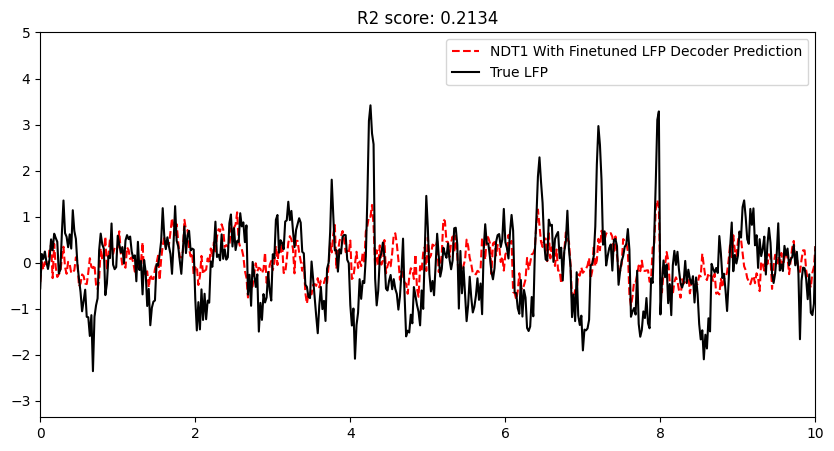

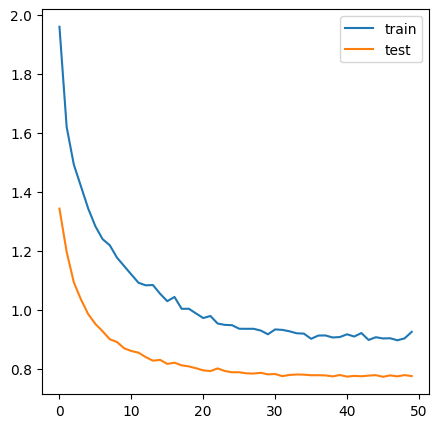

In [122]:
with torch.no_grad():
    sample_batch = next(iter(test_dataloader))
    sample_spikes, sample_lfp = sample_batch[0].to(device), sample_batch[1].to(device)
    
    ndt1_lfp_prediction = fine_tuned_model.forward(sample_spikes)

t = np.linspace(0, ndt1_lfp_prediction.shape[0] * ndt1_lfp_prediction.shape[1] * bin_size, ndt1_lfp_prediction.shape[0] * ndt1_lfp_prediction.shape[1])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t,ndt1_lfp_prediction.cpu().numpy().flatten(), '--r', label='NDT1 With Finetuned LFP Decoder Prediction')
ax.plot(t,sample_lfp.cpu().numpy().flatten(), 'k' ,label='True LFP')
ax.set_xlim([0, 10])
ax.set_title(f'R2 score: {r2_score(sample_lfp.cpu().numpy().flatten(), ndt1_lfp_prediction.cpu().numpy().flatten()):.4f}')
ax.legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(train_losses, label="train")
ax.plot(test_losses,  label="test")
ax.legend()
plt.show()

In [123]:
new_decoder_model = NDT1WithNewLFPDecoder(copy.deepcopy(model))
train_losses, test_losses = new_decoder_model.train(train_dataloader, test_dataloader)

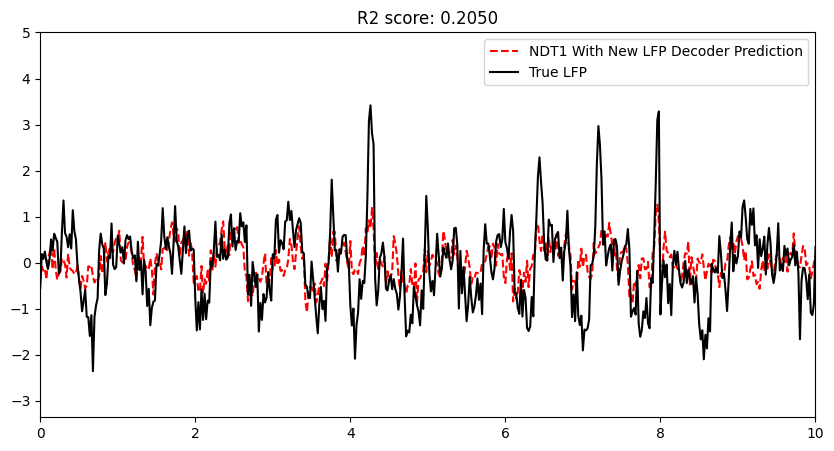

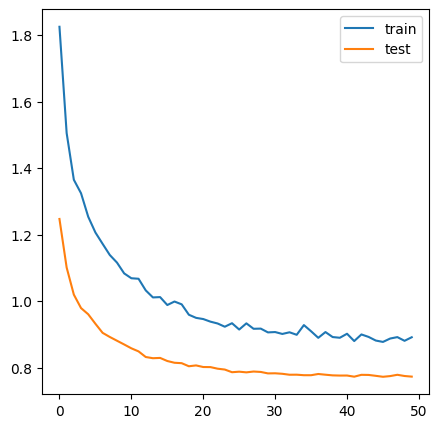

In [124]:
with torch.no_grad():
    sample_batch = next(iter(test_dataloader))
    sample_spikes, sample_lfp = sample_batch[0].to(device), sample_batch[1].to(device)
    
    ndt1_lfp_prediction = new_decoder_model.forward(sample_spikes)

t = np.linspace(0, ndt1_lfp_prediction.shape[0] * ndt1_lfp_prediction.shape[1] * bin_size, ndt1_lfp_prediction.shape[0] * ndt1_lfp_prediction.shape[1])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t,ndt1_lfp_prediction.cpu().numpy().flatten(), '--r', label='NDT1 With New LFP Decoder Prediction')
ax.plot(t,sample_lfp.cpu().numpy().flatten(), 'k' ,label='True LFP')
ax.set_xlim([0, 10])
ax.set_title(f'R2 score: {r2_score(sample_lfp.cpu().numpy().flatten(), ndt1_lfp_prediction.cpu().numpy().flatten()):.4f}')
ax.legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(train_losses, label="train")
ax.plot(test_losses,  label="test")
ax.legend()
plt.show()
plt.show()